<a href="https://www.kaggle.com/code/mstjafreenjahan/cse-366-task-2-pre-trained-model-group-5?scriptVersionId=312727447" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, roc_curve
)
from sklearn.preprocessing import label_binarize
from scipy.stats import ttest_rel

import tensorflow as tf
from tensorflow.keras import layers, models

from tensorflow.keras.applications import ResNet50, VGG16, EfficientNetB3
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_preprocess
from tensorflow.keras.applications.efficientnet import preprocess_input as eff_preprocess

from tensorflow.keras.preprocessing.image import ImageDataGenerator

2026-04-19 01:48:14.758510: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776563294.973932      22 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776563295.044165      22 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776563295.593090      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776563295.593135      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776563295.593138      22 computation_placer.cc:177] computation placer alr

In [2]:
IMG_SIZE = (300, 300)
BATCH_SIZE = 32

base_dir = "/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray"

train_dir = base_dir + "/train"
val_dir   = base_dir + "/val"
test_dir  = base_dir + "/test"

# --- EfficientNet preprocessing used as standard (BEST PERFORMANCE) ---
train_datagen = ImageDataGenerator(
    preprocessing_function=eff_preprocess,
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(
    preprocessing_function=eff_preprocess
)

train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

val_data = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

test_data = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

# Class weights (IMPORTANT for imbalance)
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_data.classes),
    y=train_data.classes
)

class_weights = dict(enumerate(class_weights))
print("Class Weights:", class_weights)

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
Class Weights: {0: np.float64(1.9448173005219984), 1: np.float64(0.6730322580645162)}


In [3]:
def build_model(base_model, fine_tune_layers=80):

    # Freeze most layers
    for layer in base_model.layers[:-fine_tune_layers]:
        layer.trainable = False

    # Fine-tune top layers
    for layer in base_model.layers[-fine_tune_layers:]:
        layer.trainable = True

    x = base_model.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    output = layers.Dense(1, activation='sigmoid')(x)

    model = models.Model(inputs=base_model.input, outputs=output)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=5e-6),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

In [4]:
def train_model(model, name):

    start_time = time.time()

    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            patience=4,
            restore_best_weights=True
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            patience=2,
            factor=0.3
        )
    ]

    history = model.fit(
        train_data,
        validation_data=val_data,
        epochs=20,
        class_weight=class_weights,
        callbacks=callbacks,
        verbose=1
    )

    train_time = time.time() - start_time
    return history, train_time

In [5]:
def evaluate_model(model, name):

    start_time = time.time()

    preds = model.predict(test_data)
    preds_binary = (preds > 0.5).astype(int).flatten()

    test_time = time.time() - start_time

    y_true = test_data.classes

    acc = accuracy_score(y_true, preds_binary)
    prec = precision_score(y_true, preds_binary)
    rec = recall_score(y_true, preds_binary)
    f1 = f1_score(y_true, preds_binary)

    cm = confusion_matrix(y_true, preds_binary)

    class_acc = cm.diagonal() / cm.sum(axis=1)

    auc = roc_auc_score(y_true, preds)

    fpr, tpr, _ = roc_curve(y_true, preds)

    return {
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "confusion_matrix": cm,
        "class_accuracy": class_acc,
        "auc": auc,
        "fpr": fpr,
        "tpr": tpr,
        "test_time": test_time
    }

In [6]:
models_dict = {
    
    "EfficientNetB3": build_model(
        EfficientNetB3(weights='imagenet', include_top=False, input_shape=(300,300,3)),
        fine_tune_layers=50
    ),

      "ResNet50": build_model(
        ResNet50(weights='imagenet', include_top=False, input_shape=(300,300,3)),
        fine_tune_layers=50
    ),

    "VGG16": build_model(
        VGG16(weights='imagenet', include_top=False, input_shape=(300,300,3)),
        fine_tune_layers=50
    )
}

results = {}
train_times = {}

for name, model in models_dict.items():
    print(f"\nTraining {name}...")
    _, train_time = train_model(model, name)
    train_times[name] = train_time

    print(f"Evaluating {name}...")
    results[name] = evaluate_model(model, name)


I0000 00:00:1776563325.661072      22 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1776563325.667558      22 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

Training EfficientNetB3...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20


I0000 00:00:1776563355.346601      89 service.cc:152] XLA service 0x7d05d083dd50 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776563355.346658      89 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1776563355.346664      89 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1776563359.806924      89 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-04-19 01:49:32.473328: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-19 01:49:32.629386: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-19 01:49:33.075657: E external/local_xl

...

163/163 ━━━━━━━━━━━━━━━━━━━━ 247s 1s/step - accuracy: 0.4883 - loss: 0.8409 - val_accuracy: 0.8125 - val_loss: 0.4751 - learning_rate: 5.0000e-06
Epoch 2/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 129s 789ms/step - accuracy: 0.7026 - loss: 0.5057 - val_accuracy: 0.8125 - val_loss: 0.3622 - learning_rate: 5.0000e-06
Epoch 3/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 128s 781ms/step - accuracy: 0.7869 - loss: 0.3963 - val_accuracy: 0.8125 - val_loss: 0.3295 - learning_rate: 5.0000e-06
Epoch 4/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 130s 795ms/step - accuracy: 0.8425 - loss: 0.3305 - val_accuracy: 0.8125 - val_loss: 0.2862 - learning_rate: 5.0000e-06
Epoch 5/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 126s 772ms/step - accuracy: 0.8574 - loss: 0.2910 - val_accuracy: 0.8750 - val_loss: 0.2365 - learning_rate: 5.0000e-06
Epoch 6/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 130s 796ms/step - accuracy: 0.8819 - loss: 0.2448 - val_accuracy: 0.9375 - val_loss: 0.1994 - learning_rate: 5.0000e-06
Epoch 7/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 128s 783ms/ste

2026-04-19 03:17:33.535344: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng12{k11=2} for conv %cudnn-conv-bias-activation.42 = (f32[32,128,150,150]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,128,150,150]{3,2,1,0} %bitcast.10050, f32[128,128,3,3]{3,2,1,0} %bitcast.8579, f32[128]{0} %bitcast.10110), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", metadata={op_type="Conv2D" op_name="functional_2_1/block2_conv2_1/convolution" source_file="/usr/local/lib/python3.12/dist-packages/tensorflow/python/framework/ops.py" source_line=1200}, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"conv_result_scale":1,"activation_mode":"kNone","side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false} is taking a while...
2026-04-19 03:17:34.257143: E external/local_xla/xla/service/slow_operation_alarm.cc:140] The operation took 1.721927061s
Try

163/163 ━━━━━━━━━━━━━━━━━━━━ 295s 1s/step - accuracy: 0.7263 - loss: 0.5668 - val_accuracy: 0.9375 - val_loss: 0.1852 - learning_rate: 5.0000e-06
Epoch 2/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 183s 1s/step - accuracy: 0.8921 - loss: 0.2436 - val_accuracy: 1.0000 - val_loss: 0.1061 - learning_rate: 5.0000e-06
Epoch 3/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 183s 1s/step - accuracy: 0.9296 - loss: 0.1677 - val_accuracy: 0.9375 - val_loss: 0.1907 - learning_rate: 5.0000e-06
Epoch 4/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 184s 1s/step - accuracy: 0.9463 - loss: 0.1346 - val_accuracy: 1.0000 - val_loss: 0.0665 - learning_rate: 5.0000e-06
Epoch 5/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 183s 1s/step - accuracy: 0.9537 - loss: 0.1083 - val_accuracy: 1.0000 - val_loss: 0.1088 - learning_rate: 5.0000e-06
Epoch 6/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 183s 1s/step - accuracy: 0.9634 - loss: 0.0958 - val_accuracy: 0.6875 - val_loss: 0.5113 - learning_rate: 5.0000e-06
Epoch 7/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 183s 1s/step - accuracy: 0.96

2026-04-19 03:43:47.620806: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng12{k11=2} for conv %cudnn-conv-bias-activation.42 = (f32[32,128,150,150]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,128,150,150]{3,2,1,0} %bitcast.592, f32[128,128,3,3]{3,2,1,0} %bitcast.599, f32[128]{0} %bitcast.601), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", metadata={op_type="Conv2D" op_name="functional_2_1/block2_conv2_1/convolution" source_file="/usr/local/lib/python3.12/dist-packages/tensorflow/python/framework/ops.py" source_line=1200}, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"conv_result_scale":1,"activation_mode":"kRelu","side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false} is taking a while...
2026-04-19 03:43:48.085130: E external/local_xla/xla/service/slow_operation_alarm.cc:140] The operation took 1.464517386s
Trying a

20/20 ━━━━━━━━━━━━━━━━━━━━ 38s 445ms/step


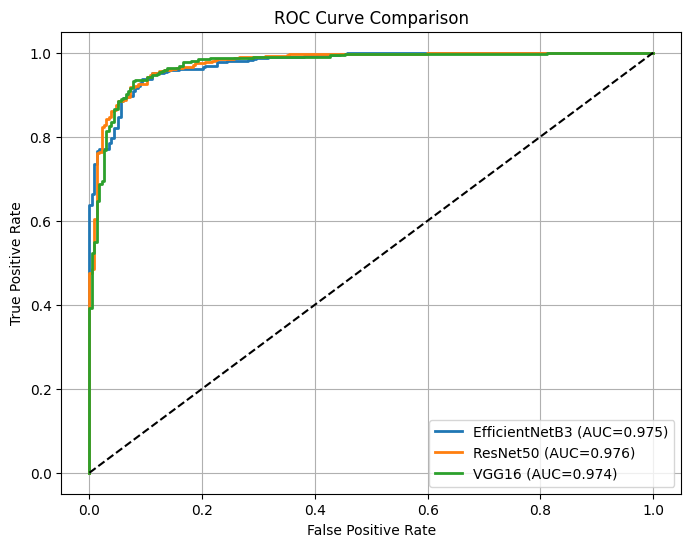

In [7]:
plt.figure(figsize=(8,6))

for name in results:
    plt.plot(
        results[name]["fpr"],
        results[name]["tpr"],
        label=f"{name} (AUC={results[name]['auc']:.3f})",
        linewidth=2
    )

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid()
plt.show()


In [8]:
summary = []

for name in results:
    summary.append({
        "Model": name,
        "Accuracy": results[name]["accuracy"],
        "Class Acc (Normal)": results[name]["class_accuracy"][0],
        "Class Acc (Pneumonia)": results[name]["class_accuracy"][1],
        "Precision": results[name]["precision"],
        "Recall": results[name]["recall"],
        "F1-score": results[name]["f1"],
        "AUC": results[name]["auc"],
        "Train Time (s)": train_times[name],
        "Test Time (s)": results[name]["test_time"]
    })

df_summary = pd.DataFrame(summary)
print(df_summary)

            Model  Accuracy  Class Acc (Normal)  Class Acc (Pneumonia)  \
0  EfficientNetB3  0.902244            0.799145               0.964103   
1        ResNet50  0.923077            0.867521               0.956410   
2           VGG16  0.921474            0.888889               0.941026   

   Precision    Recall  F1-score       AUC  Train Time (s)  Test Time (s)  
0   0.888889  0.964103  0.924969  0.974962     2695.102107      31.484794  
1   0.923267  0.956410  0.939547  0.976244     2563.307933      14.619000  
2   0.933842  0.941026  0.937420  0.973559     1579.171995      38.912998  


In [9]:
predictions = {}

for name, model in models_dict.items():
    preds = model.predict(test_data).flatten()
    predictions[name] = preds

# Example: ResNet vs VGG
t_stat, p_value = ttest_rel(predictions["ResNet50"], predictions["VGG16"])

print("T-test ResNet vs VGG:")
print("t-stat:", t_stat)
print("p-value:", p_value)

20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 255ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 257ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 405ms/step
T-test ResNet vs VGG:
t-stat: 6.290959963141953
p-value: 5.945216126803063e-10


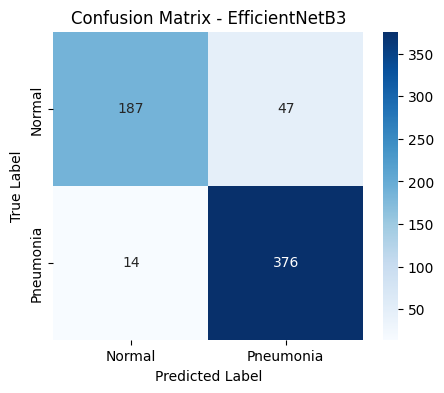

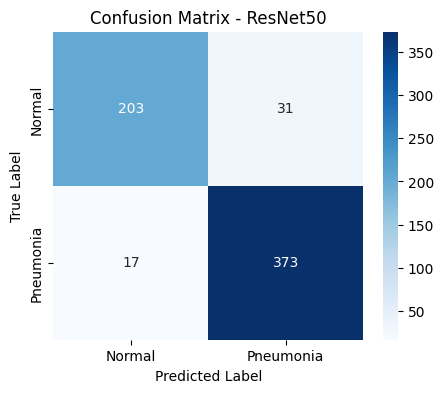

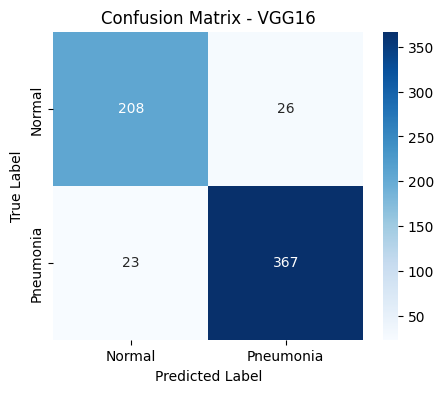

In [10]:
def plot_confusion_matrix(cm, model_name):
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=["Normal", "Pneumonia"],
                yticklabels=["Normal", "Pneumonia"])
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.show()

# Plot for all models
for name in results:
    plot_confusion_matrix(results[name]["confusion_matrix"], name)